In [1]:
!pip install tensorflow

In [10]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from keras import Model, layers
from keras.models import load_model, model_from_json
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.layers import Flatten, Dropout, BatchNormalization

In [11]:
from tensorflow.keras.callbacks import (
    Callback,
    CSVLogger,
    EarlyStopping,
    LearningRateScheduler,
    ModelCheckpoint
)

In [12]:
print(tf.__version__)
print(tf.config.list_logical_devices('GPU'))

tf.test.is_gpu_available()

2.18.0
[LogicalDevice(name='/device:GPU:0', device_type='GPU')]


True

In [13]:
data_path = '/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/EyeDiseaseDataset'

# Data Augmentation
datagen = ImageDataGenerator(
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    preprocessing_function=preprocess_input
    )
# Train generator (80%)
train_generator = datagen.flow_from_directory(
    data_path,
    subset='training',
    batch_size=32,
    class_mode='categorical',
    target_size=(256, 256),
    shuffle=True,
    )
# Validation generator (20%)
validation_generator = datagen.flow_from_directory(
    data_path,
    subset='validation',
    shuffle=False,
    class_mode='categorical',
    batch_size=32,
    target_size=(256, 256)
    )

Found 4800 images belonging to 6 classes.
Found 1200 images belonging to 6 classes.


In [ ]:
# Get the class names from the subdirectories in the training directory
class_names = sorted(os.listdir(data_path))

# Print the class names and the number of classes
print("Class Names:", class_names)
num_classes = len(class_names)
print("Number of Classes:", num_classes)

Class Names: ['Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Healthy', 'Macular Scar', 'Myopia']
Number of Classes: 6


In [ ]:
def visualize_images(path, target_size=(256, 256), num_images=5):

    # Get a list of image filenames
    image_filenames = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]

    if not image_filenames:
        raise ValueError("No images found in the specified path")

    # Select random images
    selected_images = random.sample(image_filenames, min(num_images, len(image_filenames)))

    # Create a figure and axes
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3), facecolor='white')

    # Display each image
    for i, image_filename in enumerate(selected_images):
        # Load image and resize
        image_path = os.path.join(path, image_filename)
        image = Image.open(image_path)
        image = image.resize(target_size)

        # Display image
        axes[i].imshow(image)
        axes[i].axis('off')
        axes[i].set_title(image_filename)  # Set image filename as title

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

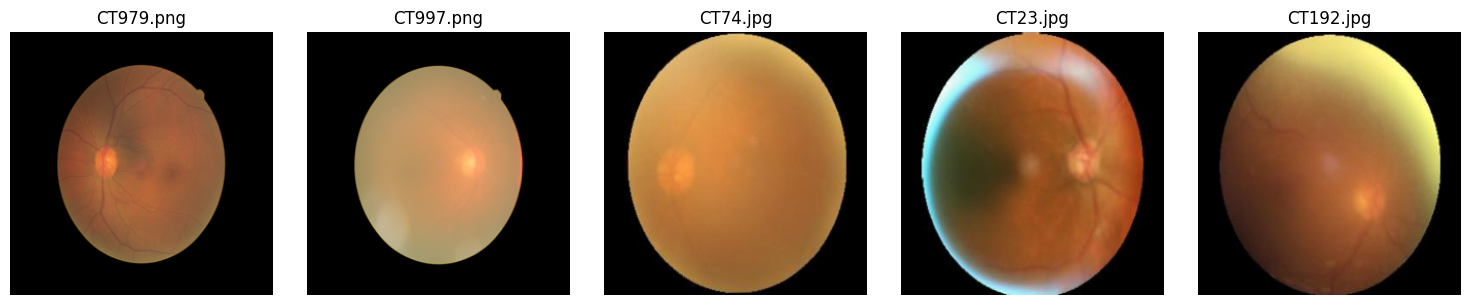

In [ ]:
# Specify the path containing the images to visualize
path_to_visualize = "/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/EyeDiseaseDataset/Cataract"

# Visualize 5 random images
visualize_images(path_to_visualize, num_images=5)

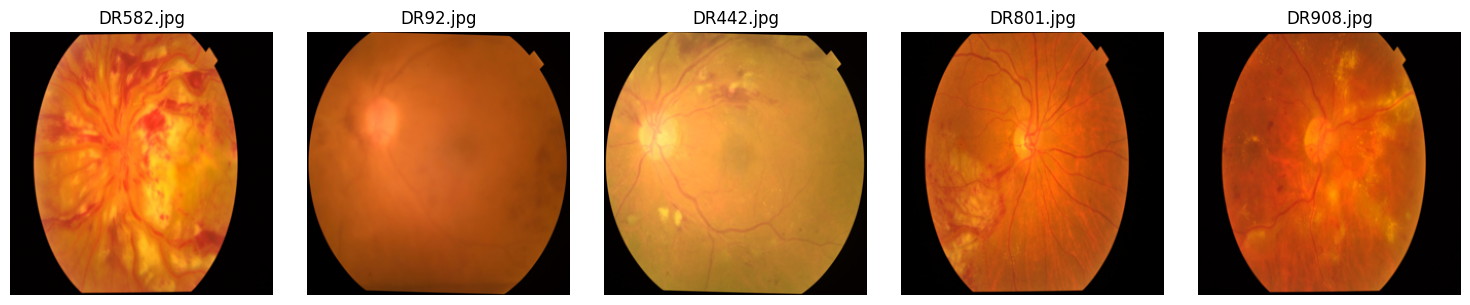

In [ ]:
# Specify the path containing the images to visualize
path_to_visualize = "/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/EyeDiseaseDataset/Diabetic Retinopathy"

# Visualize 5 random images
visualize_images(path_to_visualize, num_images=5)

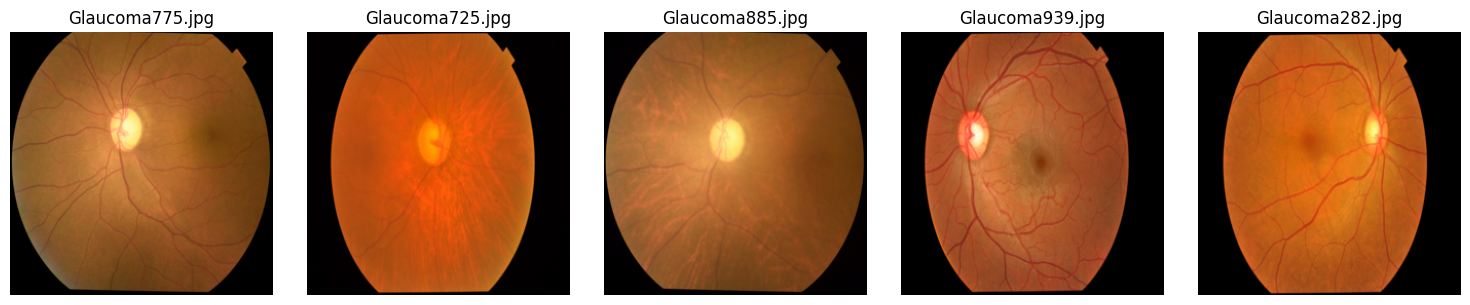

In [ ]:
# Specify the path containing the images to visualize
path_to_visualize = "/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/EyeDiseaseDataset/Glaucoma"

# Visualize 5 random images
visualize_images(path_to_visualize, num_images=5)

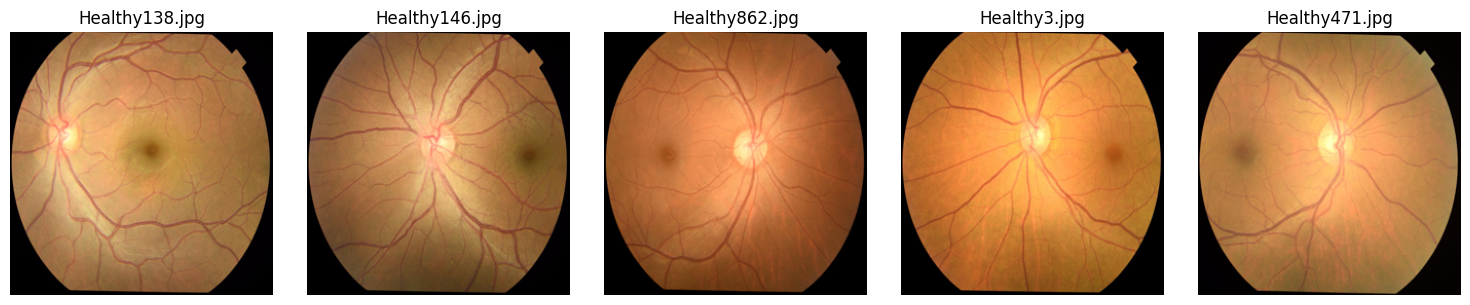

In [ ]:
# Specify the path containing the images to visualize
path_to_visualize = "/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/EyeDiseaseDataset/Healthy"

# Visualize 5 random images
visualize_images(path_to_visualize, num_images=5)

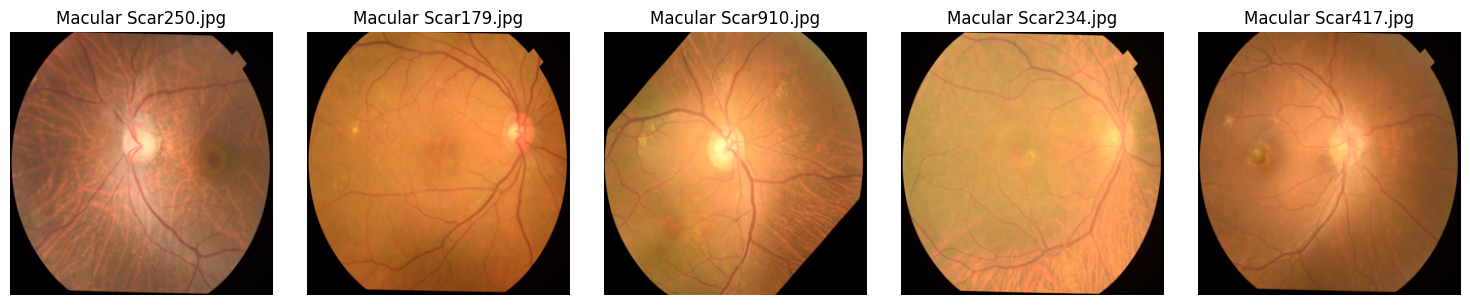

In [ ]:
# Specify the path containing the images to visualize
path_to_visualize = "/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/EyeDiseaseDataset/Macular Scar"

# Visualize 5 random images
visualize_images(path_to_visualize, num_images=5)

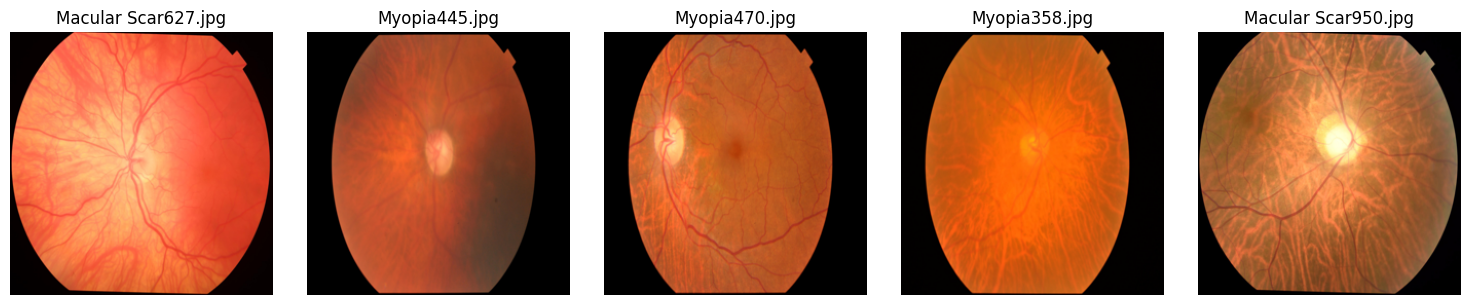

In [ ]:
# Specify the path containing the images to visualize
path_to_visualize = "/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/EyeDiseaseDataset/Myopia"

# Visualize 5 random images
visualize_images(path_to_visualize, num_images=5)

In [14]:
from tensorflow.keras import regularizers

base_model = MobileNetV2(weights='imagenet', include_top=False,
                         input_shape=(256, 256, 3))
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu', kernel_regularizer = regularizers.l2(0.01))(x)
x = layers.Dropout(0.2)(x)
predictions = layers.Dense(6, activation='softmax', kernel_regularizer = regularizers.l2(0.01))(x)
models = Model(inputs=base_model.input, outputs=predictions)
models.summary()

<ipython-input-14-eeea7d40c696>:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False,


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 2,916,934 (11.13 MB)

 Trainable params: 2,882,822 (11.00 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
checkpoint_callback = ModelCheckpoint(
    '/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/result_4/best_mobilenetv2.h5',
    monitor='val_accuracy',
    mode='max',
    verbose=1,
    save_best_only=True
)
early_stopping_callback = EarlyStopping(
    monitor='val_accuracy',
    patience=10
    restore_best_weights=True
)

csv_logger_callback = CSVLogger(
    '/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/result_4/training_history_1.csv', append=True
)

for layer in base_model.layers:
    layer.trainable = False

models.compile(loss='categorical_crossentropy',
               optimizer='adam',
               metrics=['accuracy'])

In [ ]:
# Train the model
history = models.fit(
    x=train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=[checkpoint_callback, early_stopping_callback, csv_logger_callback]
)

Epoch 1/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5225 - loss: 5.7387
Epoch 1: val_accuracy improved from -inf to 0.62083, saving model to /content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/result_4/best_mobilenetv2.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 460s 3s/step - accuracy: 0.5229 - loss: 5.7264 - val_accuracy: 0.6208 - val_loss: 2.0417
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6375 - loss: 1.7899
Epoch 2: val_accuracy improved from 0.62083 to 0.64917, saving model to /content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/result_4/best_mobilenetv2.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.6376 - loss: 1.7887 - val_accuracy: 0.6492 - val_loss: 1.3532
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6425 - loss: 1.2977
Epoch 3: val_accuracy did not improve from 0.64917
150/150 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.6426 - loss: 1.2974 - val_accuracy: 0.5517 - val_loss: 1.3440
Epoch 4/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6606 - loss: 1.1519
Epoch 4: val_accuracy did not improve from 0.64917
150/150 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.6606 - loss: 1.1517 - val_accuracy: 0.6208 - val_loss: 1.1312
Epoch 5/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6689 - loss: 1.0712
Epoch 5: val_accuracy improved from 0.64917 to 0.66250, saving model to /content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/result_4/best_mobilenetv2.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.6689 - loss: 1.0712 - val_accuracy: 0.6625 - val_loss: 1.0332
Epoch 6/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6729 - loss: 1.0157
Epoch 6: val_accuracy did not improve from 0.66250
150/150 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.6729 - loss: 1.0159 - val_accuracy: 0.6458 - val_loss: 1.0566
Epoch 7/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6682 - loss: 1.0419
Epoch 7: val_accuracy did not improve from 0.66250
150/150 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.6682 - loss: 1.0419 - val_accuracy: 0.6358 - val_loss: 1.0478
Epoch 8/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6827 - loss: 0.9974
Epoch 8: val_accuracy did not improve from 0.66250
150/150 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.6826 - loss: 0.9975 - val_accuracy: 0.6533 - val_loss: 1.0169
Epoch 9/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6805 - loss: 1.0071
Epoch 9: val_accuracy improved from

150/150 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.6804 - loss: 1.0072 - val_accuracy: 0.6758 - val_loss: 1.0063
Epoch 10/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6568 - loss: 1.0244
Epoch 10: val_accuracy did not improve from 0.67583
150/150 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.6569 - loss: 1.0243 - val_accuracy: 0.6650 - val_loss: 1.0123
Epoch 11/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6698 - loss: 1.0130
Epoch 11: val_accuracy did not improve from 0.67583
150/150 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.6698 - loss: 1.0131 - val_accuracy: 0.6642 - val_loss: 1.0068
Epoch 12/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6715 - loss: 1.0015
Epoch 12: val_accuracy did not improve from 0.67583
150/150 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.6715 - loss: 1.0015 - val_accuracy: 0.6467 - val_loss: 1.0538
Epoch 13/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6642 - loss: 1.0266
Epoch 13: val_accuracy did n

In [20]:
from tensorflow.keras.models import load_model

model_path = '/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/result_4/best_mobilenetv2.h5'
models = load_model(model_path)

In [21]:
checkpoint_callback = ModelCheckpoint(
    '/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/result_4/bestweight_mobilenetv2_2.h5',
    monitor='val_accuracy',
    mode='max',
    verbose=1,
    save_best_only=True
)
early_stopping_callback = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)
csv_logger_callback = CSVLogger(
    '/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/result_4/training_history_2.csv', append=True
)

models.compile(loss='categorical_crossentropy',
               optimizer='adam',
               metrics=['accuracy'])

In [23]:
history_resume = models.fit(
    x=train_generator,
    initial_epoch=13,
    epochs=30,
    validation_data=validation_generator,
    callbacks=[checkpoint_callback, early_stopping_callback, csv_logger_callback]
)

Epoch 14/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.6651 - loss: 1.0162 

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 14: val_accuracy improved from -inf to 0.65917, saving model to /content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/result_4/bestweight_mobilenetv2_2.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 2203s 15s/step - accuracy: 0.6652 - loss: 1.0162 - val_accuracy: 0.6592 - val_loss: 1.0485
Epoch 15/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6797 - loss: 0.9970
Epoch 15: val_accuracy did not improve from 0.65917
150/150 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.6797 - loss: 0.9971 - val_accuracy: 0.6375 - val_loss: 1.0245
Epoch 16/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6588 - loss: 1.0208
Epoch 16: val_accuracy improved from 0.65917 to 0.67417, saving model to /content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/result_4/bestweight_mobilenetv2_2.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.6589 - loss: 1.0207 - val_accuracy: 0.6742 - val_loss: 0.9827
Epoch 17/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6737 - loss: 1.0105
Epoch 17: val_accuracy did not improve from 0.67417
150/150 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.6737 - loss: 1.0104 - val_accuracy: 0.6475 - val_loss: 1.0009
Epoch 18/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6625 - loss: 0.9901
Epoch 18: val_accuracy did not improve from 0.67417
150/150 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.6625 - loss: 0.9901 - val_accuracy: 0.6583 - val_loss: 1.0149
Epoch 19/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6831 - loss: 0.9637
Epoch 19: val_accuracy did not improve from 0.67417
150/150 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.6830 - loss: 0.9639 - val_accuracy: 0.6600 - val_loss: 0.9934
Epoch 20/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6780 - loss: 0.9800
Epoch 20: val_accuracy did n

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.read_csv('/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/result_4/training_history_2.csv')

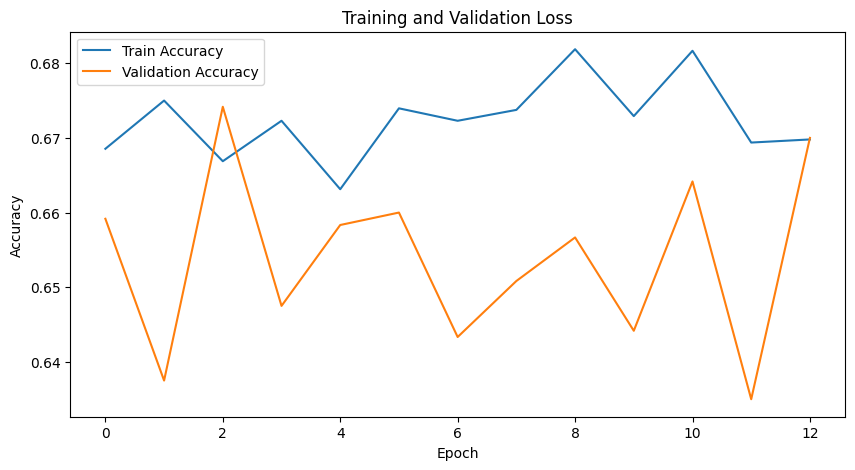

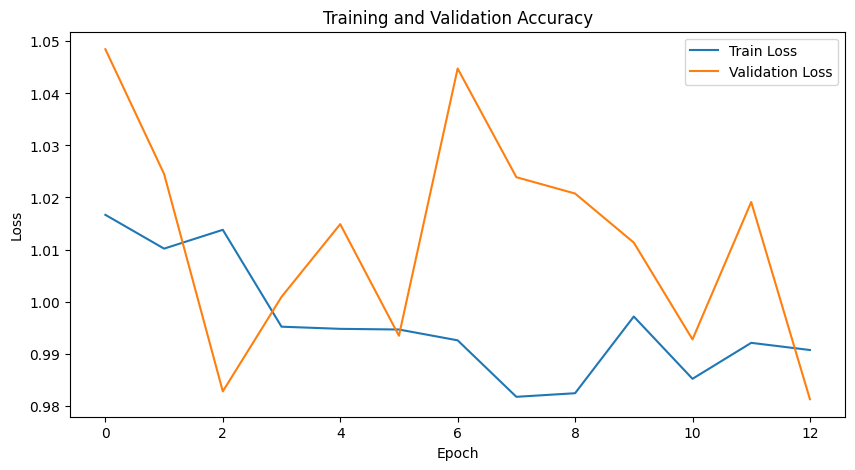

In [4]:
# Vẽ Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_df['accuracy'], label='Train Accuracy')
plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy qua các Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Loss')
plt.savefig('/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/result_4/loss_plot.webp_1', format='webp')
plt.show()

# Vẽ Loss
plt.figure(figsize=(10, 5))
plt.plot(history_df['loss'], label='Train Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Loss qua các Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.savefig('/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/result_4/accuracy_plot.webp_1', format='webp')
plt.show()

In [ ]:
model = load_model('/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/result_3/eyedisease_bestweight_mobilenetv2_2.h5')

In [ ]:
from PIL import Image

validation_img_paths = ["/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/EyeDiseaseDataset/Cataract/CT1000.png",
                        "/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/EyeDiseaseDataset/Diabetic Retinopathy/DR104.jpg",
                        "/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/EyeDiseaseDataset/Healthy/Healthy102.jpg",
                        "/content/drive/MyDrive/ChuyenDeChuyenSauTTNT2/my project/EyeDiseaseDataset/Glaucoma/Glaucoma126.jpg",
                        "/content/macular_test.jpg",
                        "/content/myopia_test.jpg"]
img_list = [Image.open(img_path) for img_path in validation_img_paths]

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


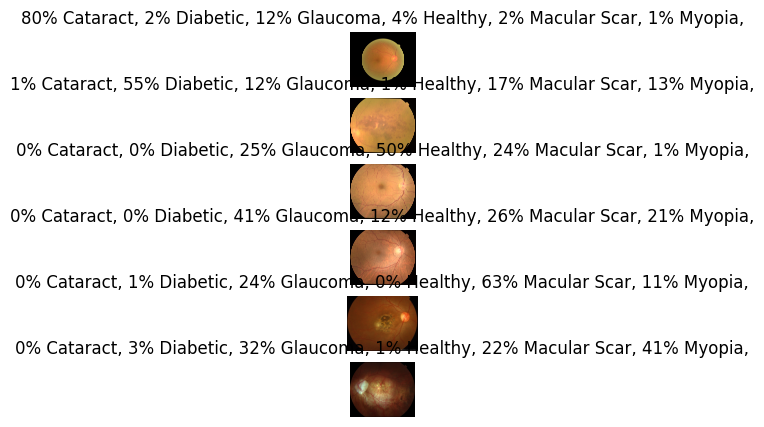

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

validation_batch = np.stack([preprocess_input(np.array(img.resize((256, 256)))) for img in img_list])

pre_prob = model.predict(validation_batch)

fig, axs = plt.subplots(6, 1, figsize=(20, 5))
for i, img in enumerate(img_list):
  ax = axs[i]
  ax.axis('off')
  ax.set_title("{:.0f}% Cataract, {:.0f}% Diabetic, {:.0f}% Glaucoma, {:.0f}% Healthy, {:.0f}% Macular Scar, {:.0f}% Myopia,".format(100*pre_prob[i][0], 100*pre_prob[i][1], 100*pre_prob[i][2], 100*pre_prob[i][3], 100*pre_prob[i][4], 100*pre_prob[i][5]))
  ax.imshow(img)